In [1]:
# !pip install torch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = sns.load_dataset('tips')

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.shape

(244, 7)

In [6]:
df.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


In [7]:
X = df[['total_bill', 'size']]
y = df['tip']

In [8]:
X.head()

,total_bill,size
0,16.99,2
1,10.34,3
2,21.01,3
3,23.68,2
4,24.59,4


In [9]:
y

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

In [10]:
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
scaler = StandardScaler()

In [12]:
X_train = scaler.fit_transform(X_train)

In [13]:
X_test = scaler.transform(X_test)

In [14]:
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

In [15]:
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

C:\Users\Acer\AppData\Local\Temp\ipykernel_4348\341643106.py:1: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)


In [16]:
y_train_tensor

tensor([[ 2.7200],
        [ 2.0300],
        [ 4.0000],
        [ 4.5000],
        [ 2.0300],
        [ 3.5100],
        [ 2.0000],
        [ 5.1500],
        [ 1.7500],
        [ 2.7400],
        [ 3.0000],
        [ 5.1400],
        [ 3.5000],
        [ 5.6500],
        [ 2.5000],
        [ 2.0100],
        [ 4.0800],
        [ 2.0900],
        [ 1.0000],
        [ 3.4100],
        [ 3.4800],
        [ 2.0000],
        [ 3.0000],
        [ 2.7100],
        [ 3.0000],
        [ 3.0000],
        [ 3.0000],
        [ 3.6800],
        [ 4.7100],
        [ 3.0000],
        [ 4.2000],
        [ 1.7300],
        [ 4.0000],
        [ 3.1500],
        [ 1.5000],
        [ 3.0000],
        [ 2.0000],
        [ 2.5000],
        [ 1.5700],
        [ 3.6000],
        [ 4.3000],
        [ 3.0600],
        [ 5.9200],
        [ 1.4800],
        [ 4.3000],
        [ 3.0000],
        [ 2.6000],
        [ 4.7300],
        [ 3.5000],
        [ 4.0000],
        [ 3.0800],
        [ 2.5400],
        [ 3.

In [17]:
class TipPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        
    def forward(self, x):
        return self.network(x)

In [18]:
model = TipPredictor()
model

TipPredictor(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [19]:
criterion = nn.MSELoss()

In [20]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [21]:
epochs = 300

loss_history = []

for epoch in range(epochs):
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    if (epoch+1) % 25 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [25/300], Loss: 2.0299
Epoch [50/300], Loss: 1.3443
Epoch [75/300], Loss: 1.1821
Epoch [100/300], Loss: 1.1176
Epoch [125/300], Loss: 1.0793
Epoch [150/300], Loss: 1.0620
Epoch [175/300], Loss: 1.0501
Epoch [200/300], Loss: 1.0398
Epoch [225/300], Loss: 1.0313
Epoch [250/300], Loss: 1.0243
Epoch [275/300], Loss: 1.0181
Epoch [300/300], Loss: 1.0120


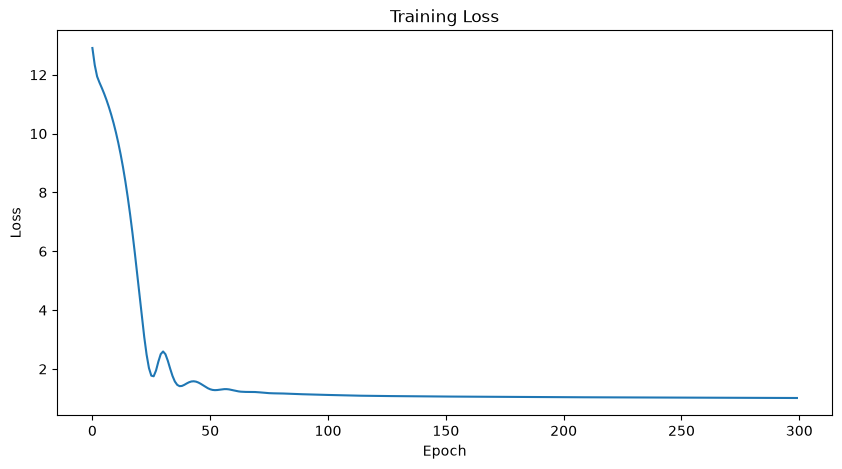

In [22]:
plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [23]:
model.eval()

TipPredictor(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [24]:
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred = y_pred.numpy()
    y_real = y_test_tensor.numpy()
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    print('Model Performance:')
    print("-" * 35)
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

Model Performance:
-----------------------------------
MAE: 0.6788
MSE: 0.7594
RMSE: 0.8715
R²: 0.3924


In [25]:
results = pd.DataFrame({
    'Actual Tip' : y_real.flatten(),
    'Predicted Tip' : y_pred.flatten()
})

In [26]:
results.head(10)

,Actual Tip,Predicted Tip
0,3.18,3.278295
1,2.00,1.851425
2,2.00,3.870473
3,5.16,4.008073
4,2.00,2.167131
5,2.00,2.946216
6,2.56,3.394164
7,2.52,2.116533
8,3.23,2.428839
9,3.00,2.513293


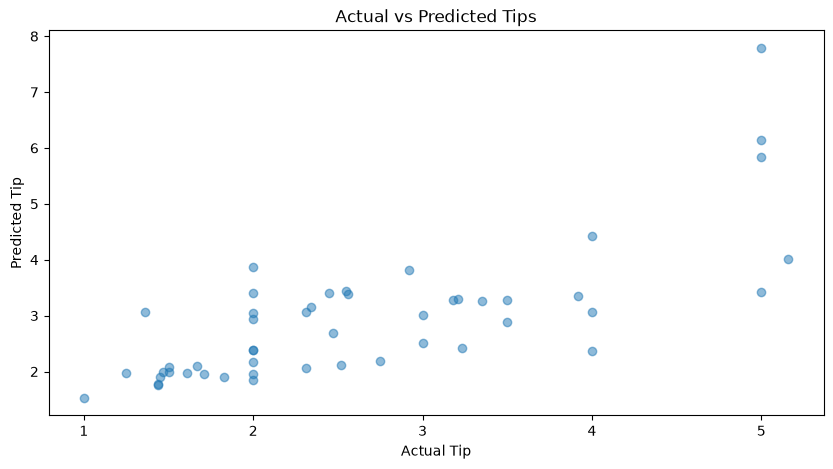

In [27]:
plt.figure(figsize=(10, 5))
plt.scatter(y_real, y_pred, alpha=0.5)
plt.xlabel('Actual Tip')
plt.ylabel('Predicted Tip')
plt.title('Actual vs Predicted Tips')
plt.show()

In [28]:
new_customer = np.array([[25.5, 2]])
new_customer = scaler.transform(new_customer)

c:\Users\Acer\Study_work Material\ML Course\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [29]:
new_customer_tensor = torch.FloatTensor(new_customer)

In [30]:
model.eval()

TipPredictor(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [31]:
with torch.no_grad():
    predicted_tip = model(new_customer_tensor)
    print(f"$ {predicted_tip.item():.2f} is the predicted tip for a total bill of $25.50 and a party size of 2.")

$ 3.42 is the predicted tip for a total bill of $25.50 and a party size of 2.


In [32]:
from sklearn.datasets import load_iris

In [33]:
iris = load_iris()

In [34]:
X = iris.data

In [35]:
y = iris.target

In [36]:
print('Feature Shape: ', X.shape)

Feature Shape:  (150, 4)


In [37]:
print('Target Shape: ', y.shape)

Target Shape:  (150,)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [39]:
scaler = StandardScaler()

In [40]:
X_train = scaler.fit_transform(X_train)

In [41]:
X_test = scaler.transform(X_test)

In [42]:
X_train_tensor = torch.FloatTensor(X_train)

In [43]:
X_test_tensor = torch.FloatTensor(X_test)

In [44]:
y_train_tensor = torch.LongTensor(y_train)

In [45]:
y_test_tensor = torch.LongTensor(y_test)

In [46]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
        
    def forward(self, x):
        return self.network(x)

In [47]:
model = IrisClassifier()

In [48]:
model

IrisClassifier(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [49]:
criterion = nn.CrossEntropyLoss()

In [50]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [51]:
epochs = 300

loss_history = []
for epoch in range(epochs):
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [20/300], Loss: 0.3232
Epoch [40/300], Loss: 0.0789
Epoch [60/300], Loss: 0.0411
Epoch [80/300], Loss: 0.0330
Epoch [100/300], Loss: 0.0286
Epoch [120/300], Loss: 0.0246
Epoch [140/300], Loss: 0.0204
Epoch [160/300], Loss: 0.0159
Epoch [180/300], Loss: 0.0116
Epoch [200/300], Loss: 0.0081
Epoch [220/300], Loss: 0.0055
Epoch [240/300], Loss: 0.0038
Epoch [260/300], Loss: 0.0027
Epoch [280/300], Loss: 0.0021
Epoch [300/300], Loss: 0.0016


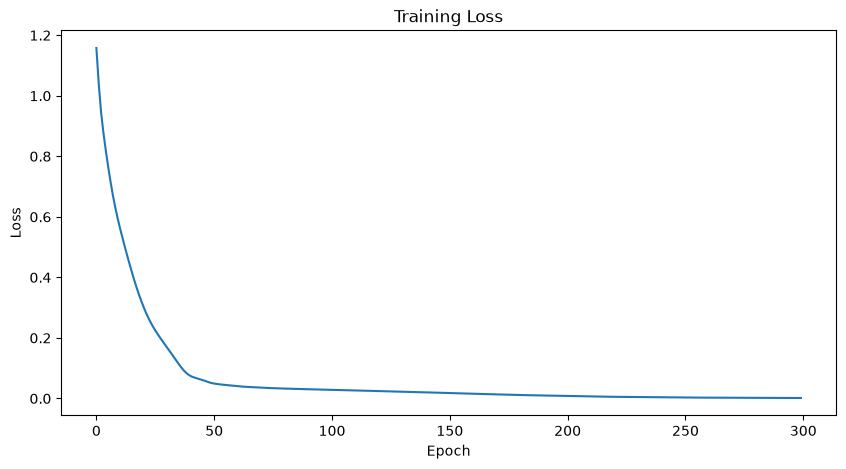

In [52]:
plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [53]:
model.eval()

IrisClassifier(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [54]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [55]:
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predictions = torch.max(outputs, 1)
    accuracy = accuracy_score(y_test_tensor.numpy(), predictions.numpy())
    print(f'Test Accuracy: {accuracy:.4f}')
    cm = confusion_matrix(y_test_tensor.numpy(), predictions.numpy())
    print('Confusion Matrix:')
    print(cm)

Test Accuracy: 0.9667
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


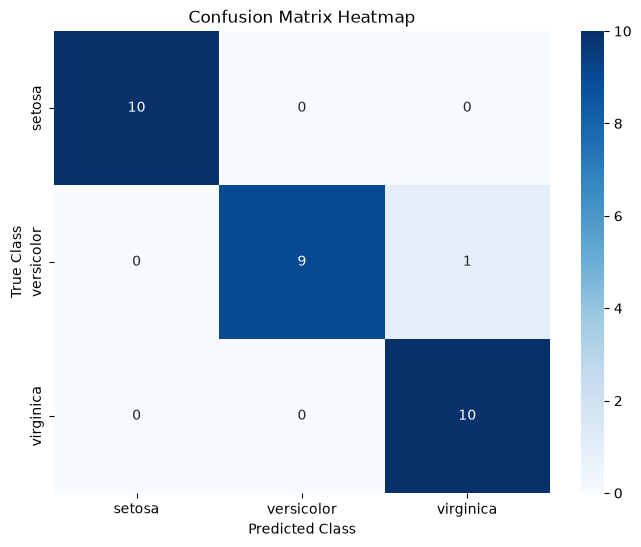

In [56]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

In [57]:
print('Classification Report:')
print(classification_report(y_test_tensor.numpy(), predictions.numpy(), target_names=iris.target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [58]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
sample = scaler.transform(sample)
sample_tensor = torch.FloatTensor(sample)

In [59]:
model.eval()

IrisClassifier(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [60]:
with torch.no_grad():
    output = model(sample_tensor)
    predicted_class = torch.argmax(output, dim=1).item()
    print("Predicted Flower: ", iris.target_names[predicted_class])

Predicted Flower:  setosa
